<a href="https://colab.research.google.com/github/Nav-del/Machine-Learning-Course/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.svm import SVC #Support Vector Classification
from sklearn import datasets

iris = datasets.load_iris()
X = iris["data"][:,(2,3)] #we only take the Petal length and petal width data points
y = iris["target"]

sentose_or_versicolor = (y == 0) | (y == 1)
X = X[sentose_or_versicolor]
y = y[sentose_or_versicolor]
#helps conver into binary dataset

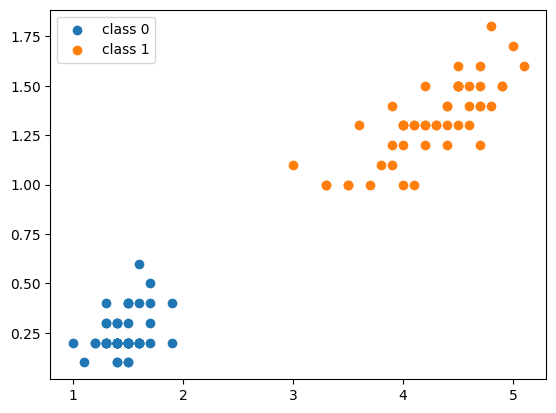

In [3]:
plt.scatter(X[:,0][y==0],X[:,1][y==0],label="class 0")
plt.scatter(X[:,0][y==1],X[:,1][y==1],label="class 1")
plt.legend()
plt.show()

SVM Classifier Model


In [5]:
svm_clv = SVC(kernel='linear',C = float('inf'))
# kernel= linear means we use straight line hyperplane
svm_clv.fit(X,y)

SVC(C=inf, kernel='linear')

C is the regularization parameter in a Support Vector Machine (SVM).It controls the trade-off between maximizing the margin (the distance between the decision boundary and the closest data points) and minimizing training classification errors.

Setting C to infinity (float('inf')) creates a Hard-Margin SVM.Zero Tolerance: The model allows absolutely zero misclassifications during training.Strict Boundary: It forces the algorithm to find a decision boundary that perfectly separates the classes.Linear Separability Requirement: This only works if your training data is perfectly linearly separable. If the data overlaps, the optimization algorithm will fail to converge.Overfitting Risk: It often leads to a very narrow margin that is highly sensitive to outliers.

In [6]:
svm_clv.coef_ #To get all the weight terms

array([[1.29411744, 0.82352928]])

In [7]:
svm_clv.intercept_ #To get bias term

array([-3.78823471])

in wx+b=0


In [12]:
#To plot the line now
def plot_svc_decision_boundary(svm_clv,xmin,xmax):
  w = svm_clv.coef_[0]
  b = svm_clv.intercept_[0]

  #At the decision boundry, w0*x0 + w1*x1 +b = 0
  # At the decision boundary, w0*x0 + w1*x1 + b = 0
  # => x1 = -w0/w1 * x0 - b/w1
  x0 = np.linspace(xmin, xmax, 200)
  decision_boundary = -w[0]/w[1] * x0 - b/w[1]

  margin = 1/w[1]
  gutter_up = decision_boundary + margin
  gutter_down = decision_boundary - margin

  svs = svm_clv.support_vectors_
  plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA') #Highlight Support Vectors
  plt.plot(x0, decision_boundary, "k-", linewidth=2)
  plt.plot(x0, gutter_up, "k--", linewidth=2)
  plt.plot(x0, gutter_down, "k--", linewidth=2)

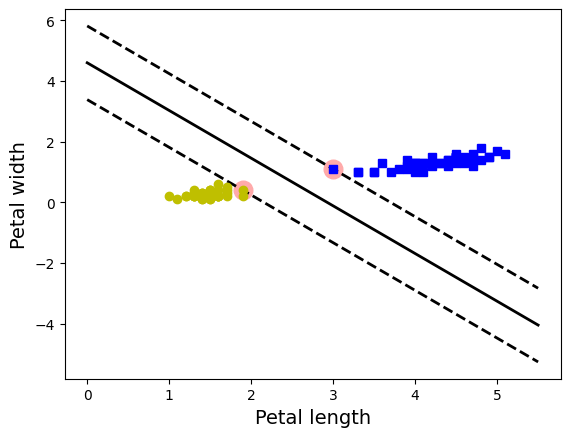

In [13]:
plot_svc_decision_boundary(svm_clv,0,5.5)
plt.plot(X[:,0][y==1],X[:,1][y==1],"bs")
plt.plot(X[:,0][y==0],X[:,1][y==0],"yo")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.show()

In [14]:
#To check where the support vectors are
svm_clv.support_vectors_

array([[1.9, 0.4],
       [3. , 1.1]])

1st -> (1.9,0.4)


2nd -> (3,1.1)

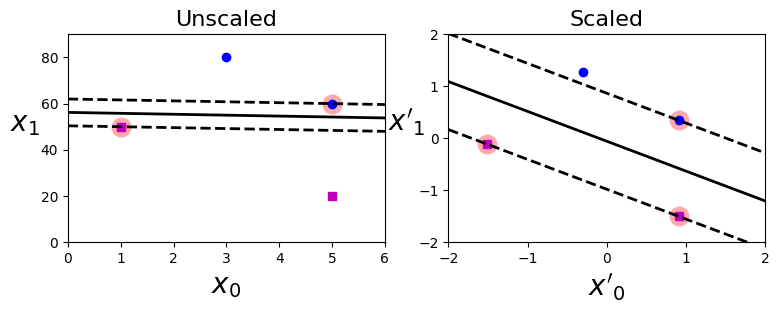

In [16]:
#To show importance of scaling
Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100)
svm_clf.fit(Xs, ys)

plt.figure(figsize=(9, 2.7))
plt.subplot(121)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$", fontsize=20)
plt.ylabel("$x_1$   ", fontsize=20, rotation=0)
plt.title("Unscaled", fontsize=16)
plt.axis([0, 6, 0, 90])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
svm_clf.fit(X_scaled, ys)

plt.subplot(122)
plt.plot(X_scaled[:, 0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:, 0][ys==0], X_scaled[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, -2, 2)
plt.xlabel("$x'_0$", fontsize=20)
plt.ylabel("$x'_1$  ", fontsize=20, rotation=0)
plt.title("Scaled", fontsize=16)
plt.axis([-2, 2, -2, 2]);


if unscaled distance between support vector and hyperplane very less, so difficult to work on it.

Polynomail

In [18]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Create a dummy non-linear dataset
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# 2. Build the pipeline with Polynomial Kernel SVM
poly_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
])

# 3. Train the model
poly_kernel_svm_clf.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

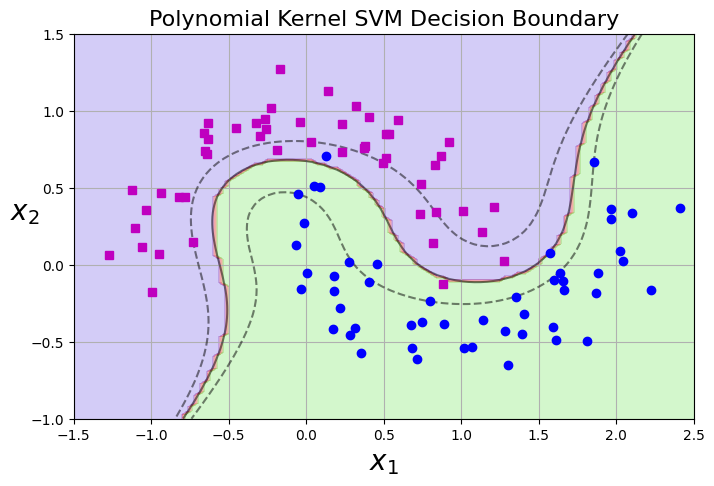

In [20]:
import matplotlib.pyplot as plt

def plot_dataset(X, y, axes):
    """Plots the data points."""
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "ms")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bo")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

def plot_predictions(clf, axes):
    """Plots the decision boundary and decision regions."""
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]

    # Predict class labels and decision scores for the grid
    y_pred = clf.predict(X_new).reshape(x0.shape)
    y_decision = clf.decision_function(X_new).reshape(x0.shape)

    # Fill the background with prediction colors
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    # Draw the contour lines for the margin/boundary
    plt.contour(x0, x1, y_decision, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Set up the figure size and plot boundaries
plt.figure(figsize=(8, 5))

# Define boundaries based on the make_moons dataset limits
axes_limits = [-1.5, 2.5, -1.0, 1.5]

# Call both functions to overlay predictions and data points
plot_predictions(poly_kernel_svm_clf, axes_limits)
plot_dataset(X, y, axes_limits)

plt.title("Polynomial Kernel SVM Decision Boundary", fontsize=16)
plt.show()

In [ ]:
*****